# DL Experiments

Обучение LSTM с использованием MLFlow

## Configuration

In [ ]:
# Хак, чтобы добавить корень проекта в path для импорта модулей
import sys
from pathlib import Path

def find_repo_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in [path, *path.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not find repo root (pyproject.toml). Open this notebook from the repo.")

REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT))
sys.path

['/home/fiberfox/Projects/HSEAIMag2025/stocks-advisor',
 '/home/fiberfox/.local/share/uv/python/cpython-3.12.7-linux-x86_64-gnu/lib/python312.zip',
 '/home/fiberfox/.local/share/uv/python/cpython-3.12.7-linux-x86_64-gnu/lib/python3.12',
 '/home/fiberfox/.local/share/uv/python/cpython-3.12.7-linux-x86_64-gnu/lib/python3.12/lib-dynload',
 '',
 '/home/fiberfox/Projects/HSEAIMag2025/stocks-advisor/.venv/lib/python3.12/site-packages',
 '__editable__.year_project-0.1.0.finder.__path_hook__']

In [ ]:
import pandas as pd
import numpy as np
from app.core.processors.feature_generator import FeatureGenerator
from app.core.database import NewsArticleRepository, get_db_session, AssetCandleRepository
from datetime import UTC, datetime
import mlflow
from jupyter_utils import setup_jupyter_notebook

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
from torch.utils.data import DataLoader
from torch import nn, optim

from stocks_dl.training.dataset import TemporalStockDataset
from stocks_dl.training.model import StockLSTMRegressor
from stocks_dl.training.train import train, calculate_metrics

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Код для загрузки конфига и подключения к MLFlow
# Для работы с продом в корне проекта должен быть .env файл с всеми нужными переменными окружения
# Для локальной разработки .env не нужен

# Подключение к проду
setup_jupyter_notebook(environment='prod', experiment='test')

# Подключение к локальным БД и MLFlow
# setup_jupyter_notebook(environment='local', experiment='test')

Environment: prod
APP_CONFIG: config.toml
Tracking URI: http://localhost:5050
S3 endpoint: http://localhost:9050
Experiment: test
Database: localhost:15432/stocks_advisor_db


## Загрузка данных

In [ ]:
# Загрузка свечей MOEX

async with get_db_session() as session:
    repo = AssetCandleRepository(session)
    candles_by_ticker = await repo.get_dataframe_by_ticker()

print(f'{len(candles_by_ticker)} tickers')
for ticker, df in candles_by_ticker.items():
    print(f'  {ticker}: {len(df)} rows')

17 tickers
  BRENT: 15612 rows
  CNYRUBF: 15577 rows
  EURRUBF: 14947 rows
  GAZP: 17154 rows
  GLDRUB_TOM: 11560 rows
  GMKN: 14926 rows
  IMOEX: 9623 rows
  LKOH: 17151 rows
  ROSN: 17148 rows
  SBER: 17151 rows
  T: 16535 rows
  TATN: 14965 rows
  TCSG: 9086 rows
  USDRUBF: 15586 rows
  VTBR: 14920 rows
  YDEX: 6725 rows
  YNDX: 7814 rows


In [ ]:
# Загрузка данных по новостям

LIMIT = 1000000

async with get_db_session() as session:
    repo = NewsArticleRepository(session)
    enrichments_df = await repo.get_all_enrichments_as_dataframe(limit=LIMIT)
enrichments_df.rename(columns={'published_at':'date'}, inplace=True)
print(f'Enrichments: {len(enrichments_df)} rows')
enrichments_df.head()

Enrichments: 191154 rows


,id,news_article_id,date,topic,tickers,sector,sentiment,sentiment_score
0,192288,16713,2022-05-01,business,[],MOEXOG,negative,0.946310
1,192289,16722,2022-05-01,politics,[],MOEXOG,negative,0.676439
2,192290,16721,2022-05-01,politics,[],MOEXRE,negative,0.909327
3,192291,16720,2022-05-01,politics,[],MOEXIT,negative,0.825744
4,192292,16719,2022-05-01,society,[],MOEXTN,negative,0.955776


## Генерация признаков

In [ ]:
# Генерация фич

features_by_ticker = {}
fg = FeatureGenerator()

for ticker, df in candles_by_ticker.items():
    features_by_ticker[ticker] = fg.process(
        df=df,
        include_original=False,
        add_targets=True,
        clean=True,
    ).drop(['target_class'], axis=1)
features_by_ticker['SBER'].head()

,begin,MA_20,MA_50,MA_90,MA_200,EMA_20,EMA_50,EMA_90,EMA_200,WMA_20,...,DISTANCE_MA_200,DISTANCE_EMA_20,DISTANCE_EMA_50,DISTANCE_EMA_90,DISTANCE_EMA_200,DISTANCE_WMA_20,DISTANCE_WMA_50,DISTANCE_WMA_90,DISTANCE_WMA_200,target_price_change
200,2022-06-02 10:00:00,120.6790,121.8344,122.674889,128.20900,120.927026,121.766630,122.704015,124.702217,120.548048,...,-0.068162,-0.012049,-0.018861,-0.026356,-0.041958,-0.008943,-0.015068,-0.022192,-0.034156,-0.912363
201,2022-06-02 12:00:00,120.5965,121.7286,122.625333,128.04905,120.843499,121.699291,122.645023,124.648846,120.488143,...,-0.062469,-0.006566,-0.013552,-0.021159,-0.036894,-0.003636,-0.009715,-0.016981,-0.028829,-1.407747
202,2022-06-02 14:00:00,120.4935,121.6098,122.569667,127.88395,120.687928,121.601642,122.568689,124.586546,120.356095,...,-0.067827,-0.012246,-0.019668,-0.027403,-0.043155,-0.009523,-0.015842,-0.023259,-0.034938,-0.914353
203,2022-06-02 16:00:00,120.3495,121.4710,122.506889,127.70375,120.492887,121.485466,122.481407,124.518533,120.179571,...,-0.070975,-0.015378,-0.023422,-0.031363,-0.047210,-0.012811,-0.019605,-0.027241,-0.038837,-0.362441
204,2022-06-02 18:00:00,120.2385,121.3390,122.442444,127.52625,120.350708,121.387970,122.404080,124.455509,120.051048,...,-0.066859,-0.011223,-0.019672,-0.027810,-0.043835,-0.008755,-0.015842,-0.023672,-0.035243,-0.672269


## Обучение

In [ ]:
def merge_tonality_with_prices(ticker, price_data, tonality_data, horizons_hours, sector_to_ticker=None):
    if sector_to_ticker is None:
        sector_to_ticker = {
            'MOEXFN': ['SBER', 'VTBR', 'TCSG'],
            'MOEXOG': ['GAZP', 'LKOH', 'ROSN', 'TATN'],
            'MOEXIT': ['YDEX'],
            'MOEXMM': ['GMKN']
        }

    result = price_data.copy()
    tonality_copy = tonality_data.copy()

    result['begin'] = pd.to_datetime(result['begin'])
    tonality_copy['date'] = pd.to_datetime(tonality_copy['date'])

    def parse_ticker_list(x):
        if x is None:
            return []
        if isinstance(x, (list, tuple, set, np.ndarray, pd.Series)):
            return [str(t).upper().strip() for t in x if str(t).strip()]
        if isinstance(x, str):
            s = x.strip('[]').strip()
            if not s:
                return []
            return [t.upper().strip().strip("'\"") for t in s.split(',') if t.strip()]
        try:
            if pd.isna(x):
                return []
        except Exception:
            pass
        sx = str(x).strip()
        if not sx or sx == '[]':
            return []
        return [t.upper().strip().strip("'\"") for t in sx.split(',') if t.strip()]

    sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}

    if 'tickers' in tonality_copy.columns:
        tonality_copy['tickers_list'] = tonality_copy['tickers'].apply(parse_ticker_list)
    else:
        tonality_copy['tickers_list'] = [[] for _ in range(len(tonality_copy))]
    if 'sentiment' in tonality_copy.columns:
        tonality_copy['sentiment_value'] = tonality_copy['sentiment'].map(sentiment_map)
    else:
        tonality_copy['sentiment_value'] = pd.Series([pd.NA] * len(tonality_copy))

    def is_news_for_ticker(row, target_ticker):
        target = target_ticker.upper()
        if target in row['tickers_list']:
            return True
        sector = str(row.get('sector', '')).upper()
        return target in [t.upper() for t in sector_to_ticker.get(sector, [])]

    news_for_ticker = tonality_copy[
        tonality_copy.apply(lambda row: is_news_for_ticker(row, ticker), axis=1)
    ].copy()

    if len(news_for_ticker) == 0:
        for h in horizons_hours:
            col = 'sentiment' if h == 2 else f'sentiment_{h}h'
            result[col] = np.nan
        return result

    for h in horizons_hours:
        col = 'sentiment' if h == 2 else f'sentiment_{h}h'
        result[col] = np.nan

    unique_times = sorted(result['begin'].unique())

    for current_time in unique_times:
        for h in horizons_hours:
            window_start = current_time - pd.Timedelta(hours=h)
            mask_news = (news_for_ticker['date'] > window_start) & (news_for_ticker['date'] <= current_time)
            window_news = news_for_ticker.loc[mask_news, 'sentiment_value'].dropna()
            if len(window_news) > 0:
                col = 'sentiment' if h == 2 else f'sentiment_{h}h'
                result.loc[result['begin'] == current_time, col] = window_news.mean()

    return result

In [ ]:
for ticker in ['SBER', 'TCSG', 'GAZP', 'LKOH', 'ROSN']:
    features_by_ticker[ticker] = merge_tonality_with_prices(
        ticker, features_by_ticker[ticker], enrichments_df, horizons_hours=[2, 24, 72, 168])

In [ ]:
for ticker in ['SBER', 'TCSG', 'GAZP', 'LKOH', 'ROSN']:
    features_by_ticker[ticker] = features_by_ticker[ticker].fillna(0)

In [ ]:
def train_test_split_by_date(df, target_column, test_size=0.2):
    df = df.sort_values('begin').reset_index(drop=True)
    split_idx = int(len(df) * (1 - test_size))
    
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    
    print(f"Train: {train_df['begin'].min()} - {train_df['begin'].max()} ({len(train_df)} samples)")
    print(f"Test:  {test_df['begin'].min()} - {test_df['begin'].max()} ({len(test_df)} samples)")
    
    X_train = train_df.drop(columns=['begin', target_column])
    y_train = train_df[target_column]
    
    X_test = test_df.drop(columns=['begin', target_column])
    y_test = test_df[target_column]
    
    print(f"Признаков: {X_train.shape[1]}")
    
    return X_train, X_test, y_train, y_test

In [ ]:
def visualize_predictions_comparison(results_df, title="Сравнение реальных и предсказанных изменений"):
    if results_df['begin'].dtype == 'object':
        results_df = results_df.copy()
        results_df['begin'] = pd.to_datetime(results_df['begin'])
    
    results_df = results_df.sort_values('begin')
    
    plt.figure(figsize=(16, 8))
    
    plt.plot(results_df['begin'], results_df['target_price_change'], 
             linewidth=2, color='#2E8B57', label='Реальное изменение', marker='o', markersize=3, alpha=0.8)
    plt.plot(results_df['begin'], results_df['predict'], 
             linewidth=2, color='#DC143C', label='Предсказанное изменение', marker='s', markersize=3, alpha=0.8)
    
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Изменение цены (%)', fontsize=12)
    plt.xlabel('Дата', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    ax = plt.gca()
    
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
X_train_SBER, X_test_SBER, y_train_SBER, y_test_SBER = train_test_split_by_date(
    df=features_by_ticker['SBER'], 
    target_column='target_price_change',
    test_size=0.2
)

X_train_TCSG, X_test_TCSG, y_train_TCSG, y_test_TCSG = train_test_split_by_date(
    df=features_by_ticker['TCSG'], 
    target_column='target_price_change',
    test_size=0.2
)

X_train_GAZP, X_test_GAZP, y_train_GAZP, y_test_GAZP = train_test_split_by_date(
    df=features_by_ticker['GAZP'], 
    target_column='target_price_change',
    test_size=0.2
)

X_train_LKOH, X_test_LKOH, y_train_LKOH, y_test_LKOH = train_test_split_by_date(
    df=features_by_ticker['LKOH'], 
    target_column='target_price_change',
    test_size=0.2
)

X_train_ROSN, X_test_ROSN, y_train_ROSN, y_test_ROSN = train_test_split_by_date(
    df=features_by_ticker['ROSN'], 
    target_column='target_price_change',
    test_size=0.2
)

Train: 2022-06-02 10:00:00 - 2025-09-02 18:00:00 (4158 samples)
Test:  2025-09-03 10:00:00 - 2026-05-16 18:00:00 (1040 samples)
Признаков: 87
Train: 2022-07-04 10:00:00 - 2024-06-10 12:00:00 (2282 samples)
Test:  2024-06-10 14:00:00 - 2024-11-20 18:00:00 (571 samples)
Признаков: 87
Train: 2022-06-02 10:00:00 - 2025-09-02 18:00:00 (4158 samples)
Test:  2025-09-03 10:00:00 - 2026-05-16 18:00:00 (1040 samples)
Признаков: 87
Train: 2022-06-02 10:00:00 - 2025-09-02 18:00:00 (4158 samples)
Test:  2025-09-03 10:00:00 - 2026-05-16 18:00:00 (1040 samples)
Признаков: 87
Train: 2022-06-02 10:00:00 - 2025-09-02 18:00:00 (4158 samples)
Test:  2025-09-03 10:00:00 - 2026-05-16 18:00:00 (1040 samples)
Признаков: 87


Сбер

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

SEQUENCE_LENGTH = 9
BATCH_SIZE = 8
HIDDEN_SIZE = 8
NUM_LAYERS = 1
DROPOUT = 0.7
NUM_EPOCHS = 10
LEARNING_RATE = 0.0005
WEIGHT_DECAY = 0.01

Device: cpu


In [ ]:
train_dataset = TemporalStockDataset(X_train_SBER, y_train_SBER, sequence_length=SEQUENCE_LENGTH)
test_dataset = TemporalStockDataset(
    X_test_SBER,
    y_test_SBER,
    sequence_length=SEQUENCE_LENGTH,
    mean=train_dataset.X_mean,
    std=train_dataset.X_std,
)
print(f'Train sequences: {len(train_dataset)}, features: {train_dataset.num_features}')
print(f'Test sequences: {len(test_dataset)}')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Создано 4150 последовательностей длины 9
Количество признаков: 87
Создано 1032 последовательностей длины 9
Количество признаков: 87


In [ ]:
model = StockLSTMRegressor(
    input_size=train_dataset.num_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Всего параметров: {total_params:,}")

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = None

Всего параметров: 3,113


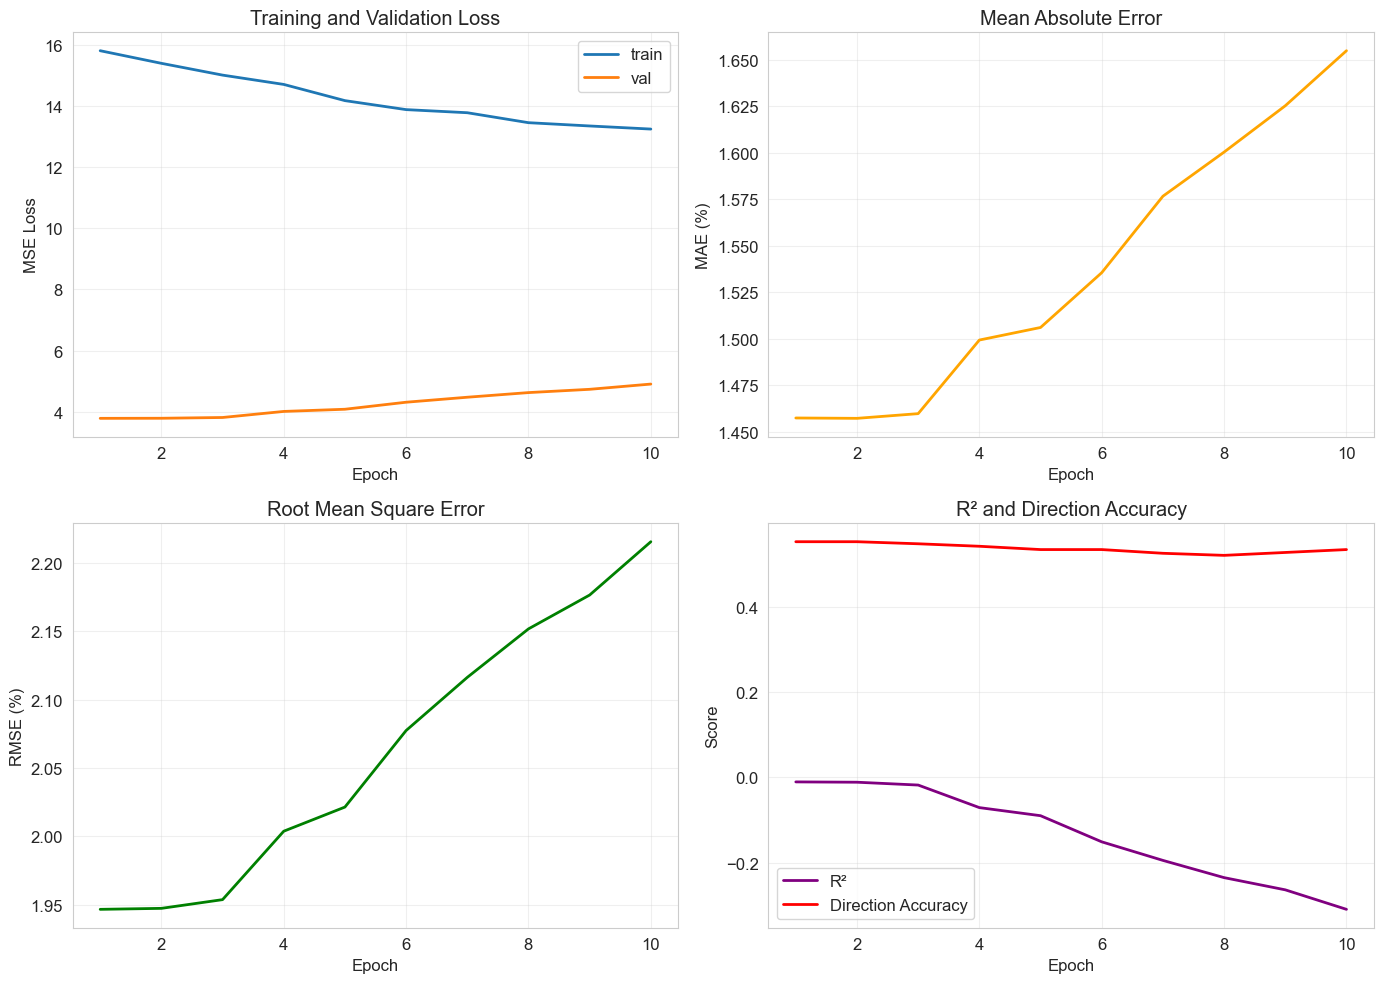


Epoch 10/10:
  Train Loss: 13.240486
  Val Loss:   4.908554
  MAE:  1.6549%
  RMSE: 2.2155%
  R²:   -0.3094
  Dir Acc: 0.5339


In [ ]:
train_losses, val_losses, val_metrics = train(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=test_loader,
    num_epochs=NUM_EPOCHS
)

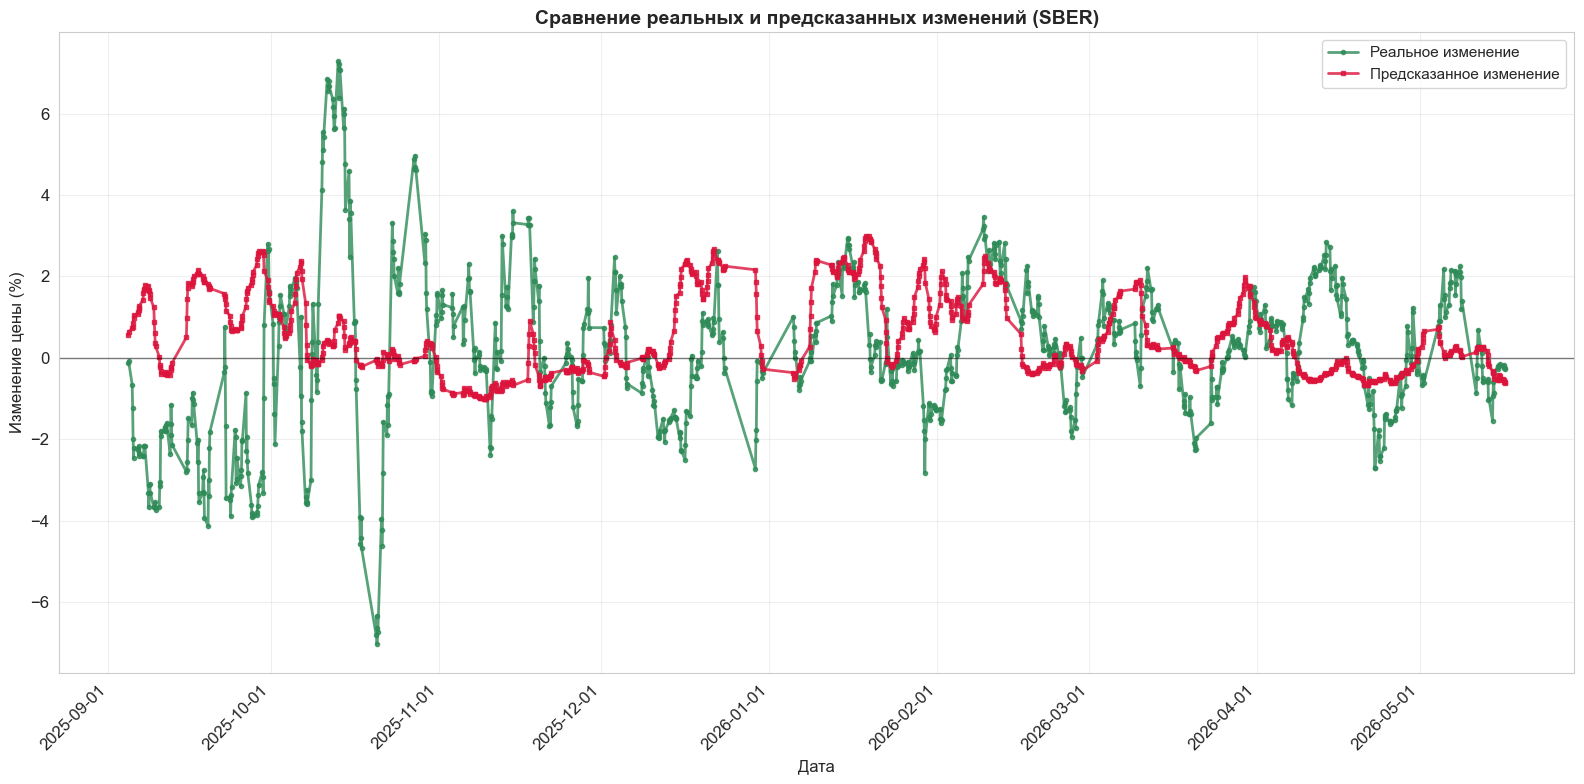

In [ ]:
model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for features, targets, lengths in test_loader:
        features = features.to(device)
        predictions = model(features, lengths.to(device))
        all_predictions.extend(predictions.cpu().numpy().flatten())
        all_targets.extend(targets.numpy().flatten())

final_metrics = calculate_metrics(np.array(all_targets), np.array(all_predictions))

results_df = pd.DataFrame({
    'begin': features_by_ticker['SBER'].iloc[-len(all_predictions):]['begin'].values,
    'target_price_change': all_targets,
    'predict': all_predictions
})

visualize_predictions_comparison(
    results_df, 
    title="Сравнение реальных и предсказанных изменений (SBER)"
)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'input_size': train_dataset.num_features,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'sequence_length': SEQUENCE_LENGTH,
    'feature_names': train_dataset.feature_names,
    'X_mean': train_dataset.X_mean,
    'X_std': train_dataset.X_std,
    'metrics': final_metrics
}

torch.save(checkpoint, 'lstm_stock_regressor_SBER.pt')

## Чекпойнт 7 — MLflow observability



- **Выбор модели:** `val_direction_accuracy` → `val_r2` → `val_rmse` (бизнес-метрика — направление).

- **PRD:** run с тегом `PRD=true`, артефакты в S3 (модель, кривые, `demo_sber_test.csv`, `data_provenance.json`).

- **Воспроизводимость:** фиксированный `seed`, гиперпараметры в params/config.json, описание данных в `data_provenance.json`.

- **Анализ ошибок:** `top_errors.csv` с категориями и пояснениями, `direction_confusion_matrix.png`, robustness CSV.

- **Демо:** [DL_Demonstration.ipynb](DL_Demonstration.ipynb) или `uv run python -m stocks_dl.cli.dl_demonstration`.


# Запуск экспериментов MlFlow

In [ ]:
import asyncio
import pandas as pd
from jupyter_utils import setup_jupyter_notebook

from stocks_dl.data.pipeline import (
    attach_tonality,
    build_features_by_ticker,
    load_candles_by_ticker,
    load_enrichments,
    merge_tonality_with_prices,
)
from stocks_dl.workflows.experiment_runner import run_search, run_prd, select_best_row
from stocks_dl.workflows.error_analysis import run_error_analysis
from stocks_dl.viz.plotting import visualize_predictions_comparison

TICKER = 'SBER'
EXPERIMENT_NAME = 'lstm_checkpoint'
SEED = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.2
FINAL_VAL_SIZE = 0.15
BATCH_SIZE = 8
WEIGHT_DECAY = 0.01
BASE_EPOCHS = 8

# setup already done above; ensure experiment
import mlflow
mlflow.set_experiment(EXPERIMENT_NAME)



In [ ]:
# Grid search (~50 runs) — долго; пропустите, если search уже в MLflow:
# !uv run python -m stocks_dl.cli.dl_experiments mode=search environment=prod

from stocks_dl.data.pipeline import load_features_and_enrichments

features_df, enrichments_df = load_features_and_enrichments(TICKER)
summary_df = run_search(
    features_df=features_df,
    ticker=TICKER,
    experiment_name=EXPERIMENT_NAME,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    seed=SEED,
    batch_size=BATCH_SIZE,
    weight_decay=WEIGHT_DECAY,
    num_epochs=BASE_EPOCHS,
    show_plots=False,
)
summary_df.head(10)



In [ ]:
# PRD: переобучение лучшей конфигурации + тег PRD + demo CSV
# CLI: uv run python -m stocks_dl.cli.dl_experiments mode=prd environment=prod

best_row = select_best_row(summary_df)
print('Best:', best_row['run_name'], 'val_dir_acc=', best_row['val_direction_accuracy'])

prd_run_summary, prd_run_id, prd_train_df, prd_val_df, test_df = run_prd(
    features_df=features_df,
    summary_df=summary_df,
    experiment_name=EXPERIMENT_NAME,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    final_val_size=FINAL_VAL_SIZE,
    seed=SEED,
    show_plots=False,
)
print('PRD run_id:', prd_run_id)
prd_run_summary



In [ ]:
# Анализ ошибок, baseline, robustness
# CLI: uv run python -m stocks_dl.cli.dl_experiments mode=analysis environment=prod prd_run_id=<id>

analysis = run_error_analysis(
    prd_run_id=prd_run_id,
    prd_run_summary=prd_run_summary,
    prd_train_df=prd_train_df,
    prd_val_df=prd_val_df,
    test_df=test_df,
    ticker=TICKER,
    enrichments_df=enrichments_df,
    experiment_name=EXPERIMENT_NAME,
)
visualize_predictions_comparison(analysis['predictions_df'], title=f'{TICKER} PRD vs test')
analysis['error_summary_df']



- Лучшая версия выбирается по `val_direction_accuracy`, затем по `val_r2`, затем по `val_rmse`.
- Дополнительное дообучение лучшего run не используется, потому что оно ухудшает качество на валидации.

## Эксперименты GAZP

Запуск 50 экспериментов для GAZP по той же схеме, что и для SBER.

In [ ]:
def build_ticker_configs(ticker_name):
    configs_local = []
    depth_grid_main_local = list(product([5, 7, 9, 12, 16], [8, 16, 32, 64], [1, 2]))
    depth_grid_deep_local = list(product([7, 9], [16, 32, 64, 96, 128], [3]))
    full_grid_local = depth_grid_main_local + depth_grid_deep_local
    for idx_local, (sequence_length, hidden_size, num_layers) in enumerate(full_grid_local, start=1):
        if num_layers == 1:
            dropout = 0.10 if hidden_size <= 32 else 0.15
            learning_rate = 6e-4 if hidden_size <= 32 else 4e-4
        elif num_layers == 2:
            dropout = 0.25 if hidden_size <= 32 else 0.30
            learning_rate = 4e-4 if hidden_size <= 32 else 3e-4
        else:
            dropout = 0.35 if hidden_size <= 64 else 0.40
            learning_rate = 3e-4 if hidden_size <= 64 else 2e-4
        configs_local.append({
            'run_name': f'{ticker_name.lower()}_exp_{idx_local:02d}',
            'ticker': ticker_name,
            'seed': SEED,
            'sequence_length': sequence_length,
            'hidden_size': hidden_size,
            'num_layers': num_layers,
            'dropout': dropout,
            'learning_rate': learning_rate,
            'batch_size': BATCH_SIZE,
            'weight_decay': WEIGHT_DECAY,
            'num_epochs': BASE_EPOCHS,
        })
    return configs_local

def run_ticker_experiments(ticker_name):
    ticker_df = features_by_ticker[ticker_name].copy()
    ticker_train_df, ticker_val_df, ticker_test_df = split_train_test(
        ticker_df,
        target_column=TARGET_COLUMN,
        test_size=TEST_SIZE,
        val_size=VAL_SIZE,
    )
    ticker_configs = build_ticker_configs(ticker_name)
    ticker_rows = []
    for cfg in ticker_configs:
        run_summary, run_id = run_experiment(
            cfg=cfg,
            train_df=ticker_train_df,
            val_df=ticker_val_df,
            test_df=ticker_test_df,
            stage='search',
            log_model=False,
        )
        ticker_rows.append(run_summary)
    ticker_summary_df = pd.DataFrame(ticker_rows).sort_values(['val_direction_accuracy', 'val_r2', 'val_rmse'], ascending=[False, False, True]).reset_index(drop=True)
    ticker_summary_df.to_csv(f'{ticker_name.lower()}_search_summary.csv', index=False)
    return ticker_summary_df

gazp_summary_df = run_ticker_experiments('GAZP')
gazp_summary_df

## Эксперименты LKOH

Запуск 50 экспериментов для LKOH по той же схеме, что и для SBER.

In [ ]:
lkoh_summary_df = run_ticker_experiments('LKOH')
lkoh_summary_df

## Эксперименты ROSN

Запуск 50 экспериментов для ROSN по той же схеме, что и для SBER.

In [ ]:
rosn_summary_df = run_ticker_experiments('ROSN')
rosn_summary_df

## Эксперименты TCSG

Запуск 50 экспериментов для TCSG по той же схеме, что и для SBER.

In [ ]:
tcsg_summary_df = run_ticker_experiments('TCSG')
tcsg_summary_df

## Пункты 1 и 2

- Для каждого тикера используется тот же helper `run_experiment`, что и для SBER: логируются гиперпараметры, train/val/test метрики, learning curves, prediction plots и конфиг эксперимента в MLflow.
- Лучший run выбирается по `val_direction_accuracy`, затем `val_r2`, затем `val_rmse`.
- Это оставляет одинаковую схему сравнения для всех тикеров и делает выбор финальной версии воспроизводимым.

In [ ]:
ticker_summaries = {
    'SBER': summary_df,
    'GAZP': gazp_summary_df,
    'LKOH': lkoh_summary_df,
    'ROSN': rosn_summary_df,
    'TCSG': tcsg_summary_df,
}

best_models_rows = []
for ticker_name, ticker_df in ticker_summaries.items():
    best_row_local = ticker_df.sort_values(['val_direction_accuracy', 'val_r2', 'val_rmse'], ascending=[False, False, True]).iloc[0]
    best_models_rows.append({
        'ticker': ticker_name,
        'run_name': best_row_local['run_name'],
        'run_id': best_row_local['run_id'],
        'sequence_length': best_row_local['sequence_length'],
        'hidden_size': best_row_local['hidden_size'],
        'num_layers': best_row_local['num_layers'],
        'dropout': best_row_local['dropout'],
        'learning_rate': best_row_local['learning_rate'],
        'val_mae': best_row_local['val_mae'],
        'val_rmse': best_row_local['val_rmse'],
        'val_r2': best_row_local['val_r2'],
        'val_direction_accuracy': best_row_local['val_direction_accuracy'],
        'test_mae': best_row_local['test_mae'],
        'test_rmse': best_row_local['test_rmse'],
        'test_r2': best_row_local['test_r2'],
        'test_direction_accuracy': best_row_local['test_direction_accuracy'],
    })

best_models_summary_df = pd.DataFrame(best_models_rows).sort_values('ticker').reset_index(drop=True)
best_models_summary_df.to_csv('best_models_summary.csv', index=False)
best_models_summary_df